<a href="https://colab.research.google.com/github/Lakshman3556/Deep_Learning/blob/main/DL_week13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implement BERT model : predicting next word in sentence, Finding missing words in sentence, review classification

In [1]:
!pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 48.6 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
from transformers import BertTokenizer, BertForMaskedLM
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForMaskedLM.from_pretrained('bert-base-uncased')

model.eval()

text = "The capital of France is [MASK]."
inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
mask_index = torch.where(inputs["input_ids"] == tokenizer.mask_token_id)[1]

predicted_token_id = logits[0, mask_index].argmax(axis=-1)
predicted_word = tokenizer.decode(predicted_token_id)

print("Predicted word:", predicted_word)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Predicted word: paris


In [3]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

model.eval()

text = "This movie was absolutely amazing!"
inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
predicted_class = torch.argmax(logits, dim=1).item()

labels = ["Negative", "Positive"]
print("Prediction:", labels[predicted_class])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Prediction: Positive


Implement GAN on MNIST

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
loader = DataLoader(dataset, batch_size=128, shuffle=True)

# Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z).view(-1, 1, 28, 28)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.0002)
opt_D = optim.Adam(D.parameters(), lr=0.0002)

# Training
for epoch in range(5):
    for real, _ in loader:
        real = real.to(device)
        batch_size = real.size(0)

        # Labels
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # Train Discriminator
        z = torch.randn(batch_size, 100).to(device)
        fake = G(z)

        loss_real = criterion(D(real), real_labels)
        loss_fake = criterion(D(fake.detach()), fake_labels)

        loss_D = loss_real + loss_fake

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train Generator
        loss_G = criterion(D(fake), real_labels)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch {epoch+1}, D Loss: {loss_D.item()}, G Loss: {loss_G.item()}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 68.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 5.39MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 25.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.01MB/s]


Epoch 1, D Loss: 0.831054151058197, G Loss: 0.9075791835784912
Epoch 2, D Loss: 1.2751730680465698, G Loss: 0.7029063105583191
Epoch 3, D Loss: 0.7563314437866211, G Loss: 1.2350226640701294
Epoch 4, D Loss: 0.9706211090087891, G Loss: 1.2563868761062622
Epoch 5, D Loss: 0.6295504570007324, G Loss: 1.5572800636291504


In [9]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

Epoch 5, D Loss: 0.6295504570007324, G Loss: 1.5572800636291504


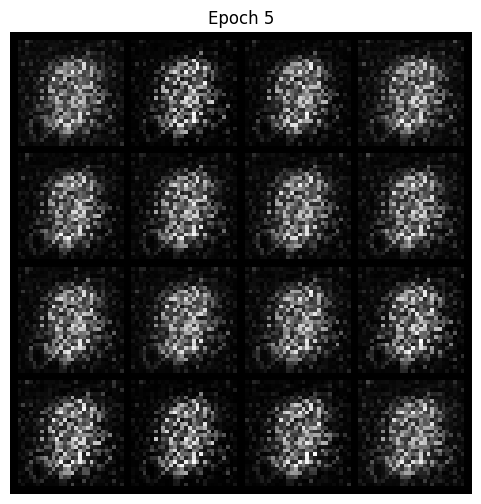

In [10]:
def show_images(images, title="Generated Images"):
    images = images.detach().cpu()
    grid = vutils.make_grid(images[:16], nrow=4, normalize=True)

    plt.figure(figsize=(6,6))
    plt.title(title)
    plt.imshow(grid.permute(1,2,0))
    plt.axis("off")
    plt.show()
# After each epoch
print(f"Epoch {epoch+1}, D Loss: {loss_D.item()}, G Loss: {loss_G.item()}")

# Generate and display images
z = torch.randn(16, 100).to(device)
fake_images = G(z)

show_images(fake_images, title=f"Epoch {epoch+1}")

In [8]:
real_score = D(real[:5]).detach().cpu().numpy()
fake_score = D(fake[:5]).detach().cpu().numpy()

print("Real Scores:", real_score.flatten())
print("Fake Scores:", fake_score.flatten())

Real Scores: [0.87895846 0.62676764 0.99002844 0.78006643 0.92764354]
Fake Scores: [0.26802328 0.0887706  0.24917695 0.21863274 0.1810793 ]


Epoch 1, D Loss: 0.9512, G Loss: 0.8203


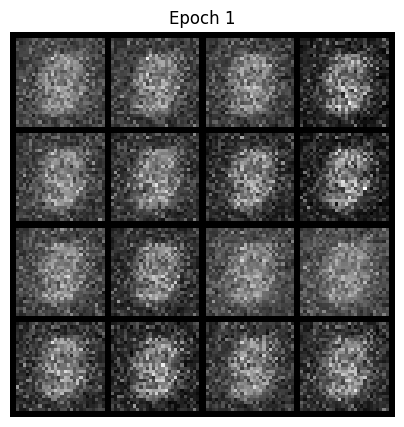

Epoch 2, D Loss: 1.0285, G Loss: 0.9599


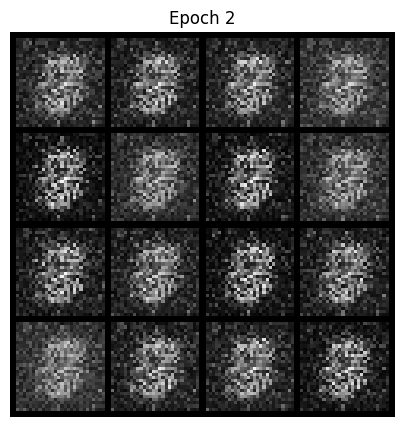

Epoch 3, D Loss: 1.1637, G Loss: 0.8635


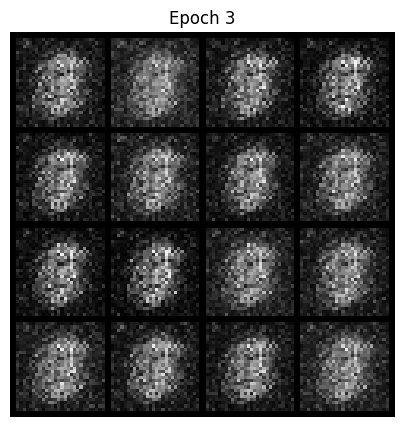

Epoch 4, D Loss: 0.9949, G Loss: 1.3057


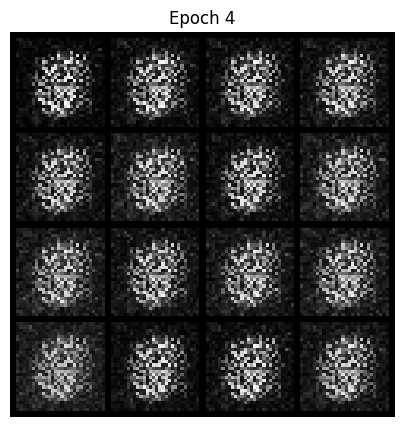

Epoch 5, D Loss: 0.9935, G Loss: 1.1474


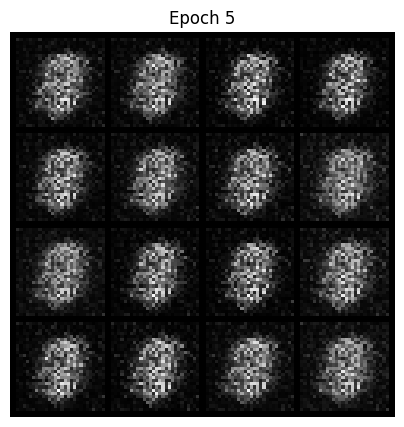

Training Complete


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torch.utils.data import DataLoader
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------
# Dataset
# ---------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
loader = DataLoader(dataset, batch_size=128, shuffle=True)

# ---------------------------
# Generator
# ---------------------------
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z).view(-1, 1, 28, 28)

# ---------------------------
# Discriminator
# ---------------------------
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.0002)
opt_D = optim.Adam(D.parameters(), lr=0.0002)

# ---------------------------
# Visualization Function
# ---------------------------
def show_images(images, title="Generated Images"):
    images = images.detach().cpu()
    grid = vutils.make_grid(images[:16], nrow=4, normalize=True)

    plt.figure(figsize=(5,5))
    plt.title(title)
    plt.imshow(grid.permute(1,2,0))
    plt.axis("off")
    plt.show()

# Optional: save images
os.makedirs("gan_images", exist_ok=True)

# ---------------------------
# Training Loop
# ---------------------------
epochs = 5

for epoch in range(epochs):
    for real, _ in loader:
        real = real.to(device)
        batch_size = real.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ---------------------
        # Train Discriminator
        # ---------------------
        z = torch.randn(batch_size, 100).to(device)
        fake = G(z)

        loss_real = criterion(D(real), real_labels)
        loss_fake = criterion(D(fake.detach()), fake_labels)

        loss_D = loss_real + loss_fake

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # ---------------------
        # Train Generator
        # ---------------------
        loss_G = criterion(D(fake), real_labels)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    # ---------------------
    # End of Epoch Output
    # ---------------------
    print(f"Epoch {epoch+1}, D Loss: {loss_D.item():.4f}, G Loss: {loss_G.item():.4f}")

    # Generate images
    z = torch.randn(16, 100).to(device)
    fake_images = G(z)

    # Show images
    show_images(fake_images, title=f"Epoch {epoch+1}")

    # Save images
    vutils.save_image(fake_images, f"gan_images/epoch_{epoch+1}.png", normalize=True)

print("Training Complete")